# Extended Figure

Split from `ahmm_final_figures.ipynb`. Covers the all-session heatmap view built from `dfv_rand_25`.


In [1]:
import pickle
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ahmm_eval import (
    build_cat_ids_from_obs_labels,
    build_conditioned_obs_heatmap,
    build_similarity_matrix,
    build_within_session_pv_cov_df_best_models,
    collect_left_tuning_all_sessions_from_df,
    collect_pv_lag_curves_for_best_models,
    compute_state_tuning_all_obs,
    load_best_pde_model_for_session,
    load_within_session_model_for_session,
    model_action_distribution_all_sessions,
    obs_heatmap_corr_for_session_and_model,
    prepare_obs_heatmap_crosscorr_2x2,
    sample_ahmm,
    save_pv_df_to_mat,
    select_left_bar_tuning,
    prep_dfv_for_heatmap,
        repair_model_paths,
    resolve_data_path,
)
from ahmm_plotting import (
    build_obs_raster_sorted,
    make_obs_colors,
    parula,
    plot_conditioned_obs_heatmap,
    plot_confusion_heatmap,
    plot_heatmap_and_pc_loadings,
    plot_metric_heatmap,
    plot_model_action_heatmap,
    plot_obj1_tuning_heatmap,
    plot_obs_raster_sorted,
    plot_pv_df_violin_sanity,
    plot_pv_lag_mean_sem,
    plot_tuning_heatmap,
    show_pv_representation_ahmm_dataset,
)
from ahmm_utils import (
    SingleTrackConfig,
    SingleTrackGenerator,
    Vocab,
    build_vocab,
    load_ahmm,
    make_session_lookup,
    records_to_dataset,
    train_test_split_random,
)




In [3]:
sessions_combined = pd.read_pickle(resolve_data_path('sessions_combined.pkl', data_roots=('data','demo_data','.')))



In [91]:
heights_in_data = sorted({
    int(h) for sess in sessions_combined for (h, _, _) in sess["records"]
} | {
    int(h) for sess in sessions_combined for (_, h, _) in sess["records"]
})
heights = heights_in_data  # or overwrite with your canonical list if you prefer

vocab: Vocab = build_vocab(heights, height_encoding='split')

# Your deterministic task config (you can change these to experiment)
cfg = SingleTrackConfig(
    tower_heights=heights,
    height_encoding='split',
    p_gap=1.0,
    p_reward_given_correct=1.0,
    p_reward_given_incorrect=0.0
)
gen = SingleTrackGenerator(vocab, cfg)

action_labels = [vocab.id_to_action[i] for i in range(len(vocab.id_to_action))]
obs_labels    = [k for k,_ in sorted(vocab.obs_to_id.items(), key=lambda kv: kv[1])]
obs_colors    = make_obs_colors(obs_labels)
sess_by_key = make_session_lookup(sessions_combined)




In [5]:
dfv_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("dfv_rand_25.pkl", data_roots=("data","demo_data","."))))



In [6]:
df_25_rand = repair_model_paths(pd.read_pickle(resolve_data_path("df_25_rand.pkl", data_roots=("data","demo_data","."))))



In [7]:
dfv_35 = repair_model_paths(pd.read_pickle(resolve_data_path("dfv_35.pkl", data_roots=("data","demo_data","."))))



In [8]:
df_35 = repair_model_paths(pd.read_pickle(resolve_data_path("df_35.pkl", data_roots=("data","demo_data","."))))



In [9]:
cg_df_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("rand_train_val_cg_rank1_pde_behavior_cross_compare_results_25_states.pkl", data_roots=("data","demo_data","."))))



### Extended Figure

In [36]:
dfv_rand_25



,test_key,train_session_key,model_key,group,similarity,rank_in_test
0,"(G375, 2023-02-27)","(G375, 2023-02-23)","(G375, 2023-02-23, 13)",BA,0.079368,2.0
1,"(G386, 2023-10-30)","(G375, 2023-02-23)","(G375, 2023-02-23, 13)",BA,-0.022077,5.0
2,"(G386, 2023-11-08)","(G375, 2023-02-23)","(G375, 2023-02-23, 13)",BA,0.136873,21.0
3,"(G410, 2024-08-01)","(G375, 2023-02-23)","(G375, 2023-02-23, 13)",BA,0.387953,74.0
4,"(G420, 2025-03-20)","(G375, 2023-02-23)","(G375, 2023-02-23, 13)",BA,0.200333,20.0
...,...,...,...,...,...,...
6000,"(G386, 2023-10-24)",NaN,"(OPT, OPT)",OPT,0.361732,45.0
6001,"(G386, 2023-10-25)",NaN,"(OPT, OPT)",OPT,0.112702,4.0
6002,"(G420, 2025-02-25)",NaN,"(OPT, OPT)",OPT,0.285714,3.0
6003,"(G420, 2025-04-11)",NaN,"(OPT, OPT)",OPT,-0.284804,1.0


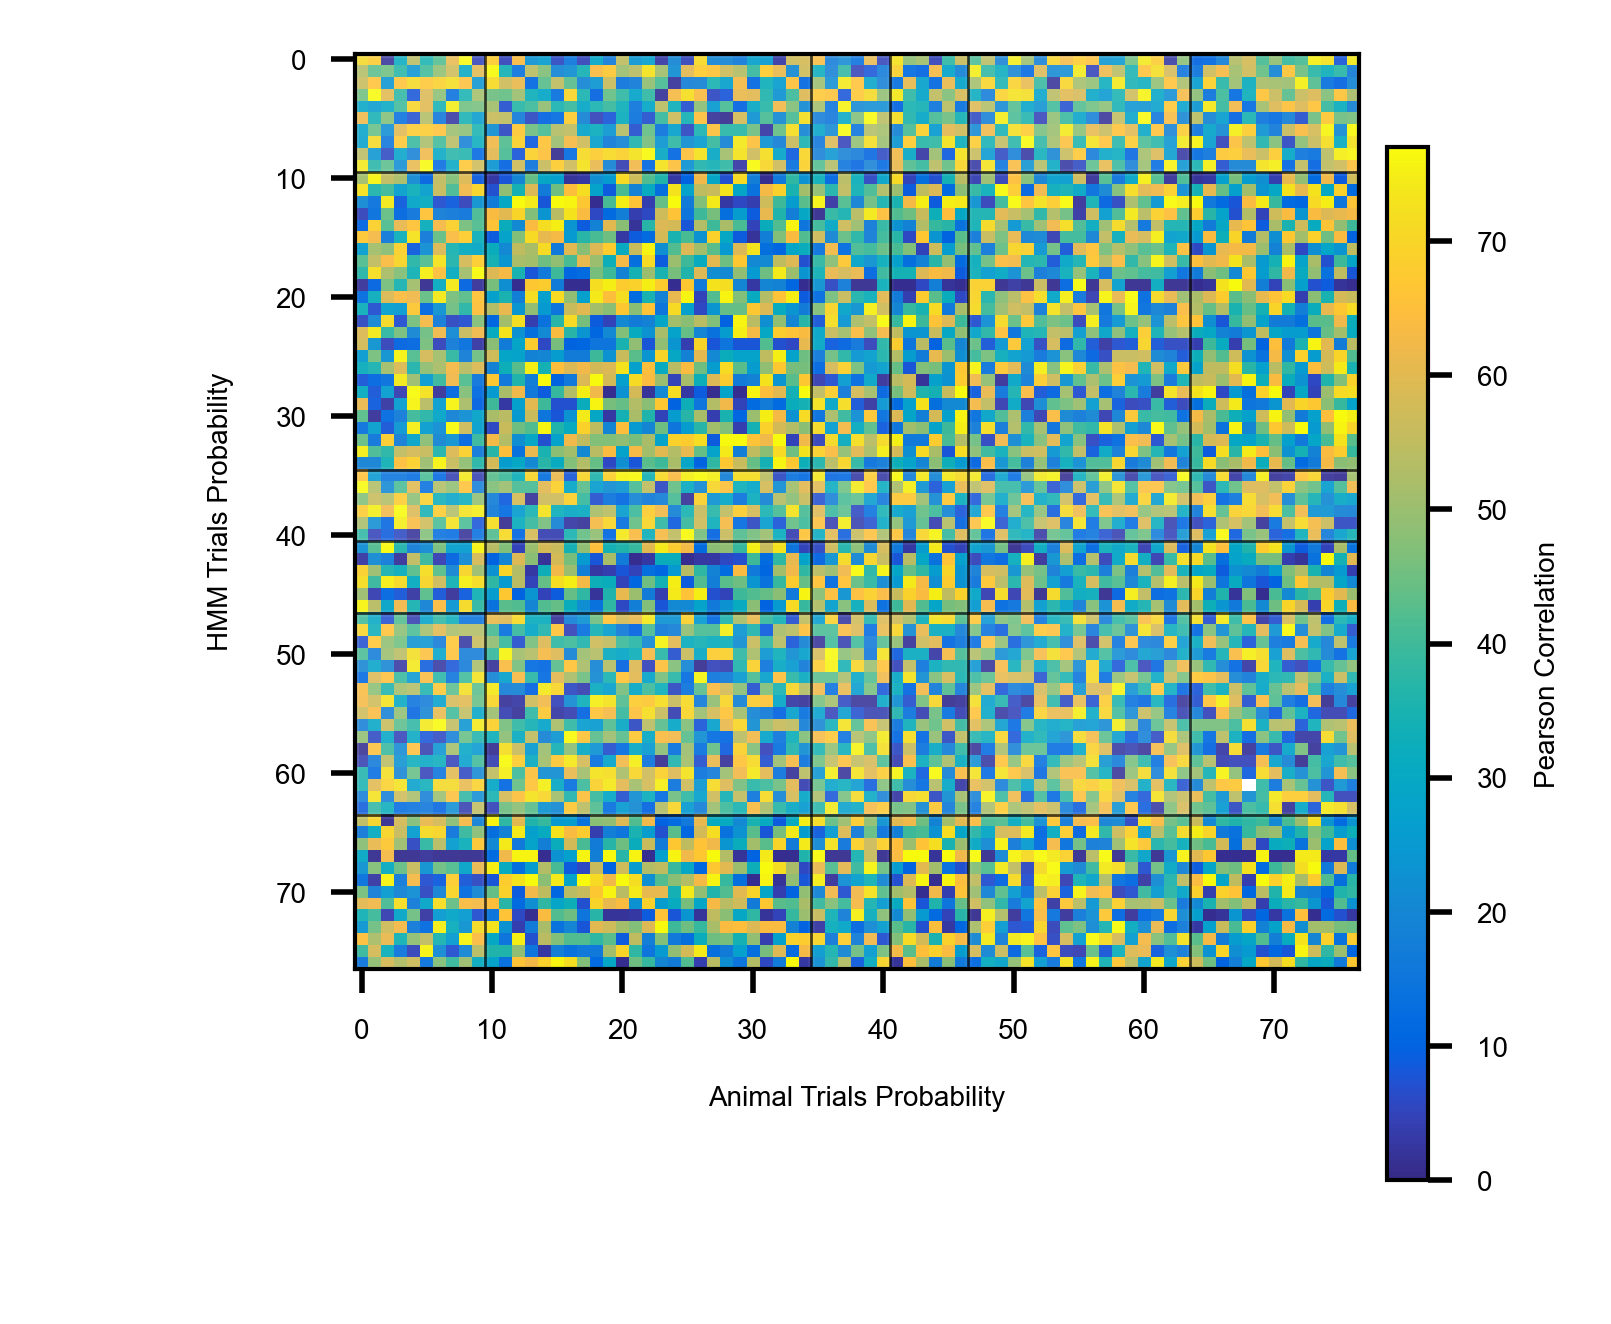

In [76]:
# usage
df_no_opt = dfv_rand_25[dfv_rand_25["group"] != "OPT"].copy()

# 2) redo rank_in_test AFTER excluding OPT
#    (assumes higher similarity = better; rank 1 = best)
df_no_opt["rank_in_test"] = (
    df_no_opt.groupby("test_key")["similarity"]
             .rank(ascending=True, method="max")
             .astype(float)
)

df_heat = prep_dfv_for_heatmap(df_no_opt)

fig, ax, P = plot_metric_heatmap(df_heat, metric="rank_in_test", figsize_cm=(10, 10), vmax=77, vmin=0, group_by="animal_date", cmap=parula, annotate=False, cbar_title="Pearson Correlation", y_label="HMM Trials Probability", x_label="Animal Trials Probability")


